In [7]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [8]:
tx_path = "/Users/levifarinas/Documents/SAR Research/Data/sweep_rx.wav"
fs, tx_raw = wavfile.read(tx_path)
tx = tx_raw[:,0].astype(np.float16) + 1j * tx_raw[:,1].astype(np.float16)
tx = tx[:1000000]

UnboundLocalError: local variable 'data' referenced before assignment

/opt/homebrew/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


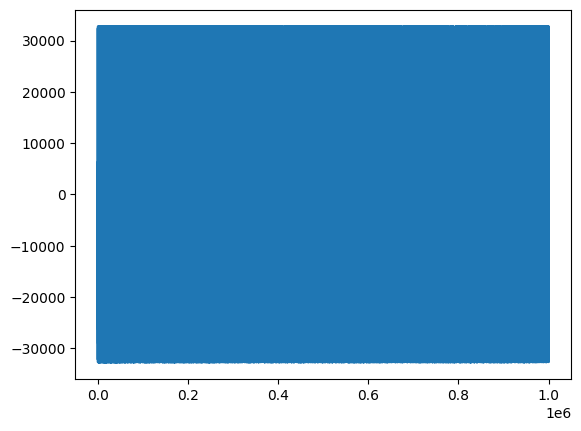

In [5]:
plt.plot(tx)

In [4]:
def inject_phase_discontinuities_with_mask(x, num_events = 20, max_drop = 200):
    N = len(x)
    keep = np.ones(N, dtype = bool)

    for _ in range(num_events):
        start = np.random.randint(0, N - max_drop)
        drop_len = np.random.randint(1, max_drop)
        keep[start:start + drop_len] = False

    x2 = x[keep]

    mask = np.zeros(N)
    edges = np.where(np.diff(keep.astype(int)) == -1)[0]
    mask[edges] = 1
    mask2 = mask[keep]

    return x2, mask2

# assume rx and fs already exist
rx_corrupted, mask = inject_phase_discontinuities_with_mask(rx, 50, 500)

t = np.arange(len(rx_corrupted)) / fs

pilot_mix = rx_corrupted * np.exp(-1j * 2 * np.pi * 4.5e6 * t)
b, a = butter(10, 100e3 / (fs / 2))
pilot = filtfilt(b, a, pilot_mix)

step = np.angle(pilot[1:] * np.conj(pilot[:-1]))
step = np.concatenate(([0], step))

step_smooth = np.convolve(step, np.ones(101) / 101, mode = "same")
err = np.abs(step - step_smooth)

start_idx = np.random.randint(0, len(rx_corrupted) - 5000)
end_idx = start_idx + 5000

scale = np.max(np.abs(rx_corrupted[start_idx:end_idx]))

err_win = err[start_idx:end_idx]
err_win = (err_win - np.min(err_win)) / (np.max(err_win) - np.min(err_win) + 1e-12)

mask_win = mask[start_idx:end_idx] * scale

plt.plot(np.abs(rx_corrupted[start_idx:end_idx]), label = "RX")
plt.plot(np.abs(pilot[start_idx:end_idx]), label = "Pilot")
plt.plot(err_win * scale, label = "Detected")
plt.plot(mask_win, label = "True", alpha=.5)

peak_idx = np.argmax(err_win)
plt.axvline(peak_idx, color = "r")

plt.legend()

NameError: name 'rx' is not defined